# Phân tích nhãn — UngLong/radiology-ready-v2

Load ready dataset, parse `response` (JSON) và thống kê phân phối nhãn từng task
(screening binary + detail multi-class).

In [1]:
import os
import json
from collections import Counter
import pandas as pd
from datasets import load_dataset

# Repo private → cần token (đổi nếu chưa login)
# os.environ["HF_TOKEN"] = "hf_..."

REPO = "UngLong/radiology-ready-v2"

/Users/macbook/Desktop/DS304_perfume_investigation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset(REPO, split="train")
df = pd.DataFrame(ds)
print(f"Tong rows: {len(df)}")
print(df["task_type"].value_counts().to_dict())
print(f"Unique CT volumes (keys): {df['keys'].nunique()}")
print(f"Unique patients (pids):   {df['pids'].nunique()}")

Tong rows: 500
{'screening': 302, 'detail': 198}
Unique CT volumes (keys): 479
Unique patients (pids):   416


## Helper: parse response JSON theo task_type

In [3]:
def label_counts(df, task_type):
    """Tra ve dict[task] = Counter(label -> so luong)."""
    sub = df[df["task_type"] == task_type]
    per_task = {}
    for resp in sub["response"]:
        obj = json.loads(resp)
        for task, ans in obj.items():
            per_task.setdefault(task, Counter())[ans] += 1
    return per_task, len(sub)

## Screening — binary (No/Yes), positive rate

In [4]:
screen, n_screen = label_counts(df, "screening")
print(f"Screening rows: {n_screen}\n")

rows = []
for task, cnt in screen.items():
    yes, no = cnt.get("Yes", 0), cnt.get("No", 0)
    tot = yes + no
    rows.append({"task": task, "No": no, "Yes": yes,
                 "%Yes": round(100 * yes / tot, 1) if tot else 0})
screen_df = pd.DataFrame(rows).sort_values("%Yes", ascending=False)
screen_df

Screening rows: 302



,task,No,Yes,%Yes
7,nodule_presence,88,214,70.9
1,chest_abn_55,140,162,53.6
5,chest_abn_59,157,145,48.0
6,chest_abn_61,191,111,36.8
2,chest_abn_56,224,78,25.8
0,chest_abn_54,275,27,8.9
4,chest_abn_58,283,19,6.3
3,chest_abn_57,297,5,1.7


In [5]:
# Canh bao task lech nang (<5% hoac >95% positive)
for _, r in screen_df.iterrows():
    if r["%Yes"] < 5 or r["%Yes"] > 95:
        print(f"  ⚠️  {r['task']}: {r['%Yes']}% Yes (lech nang -> dung F1/recall)")

  ⚠️  chest_abn_57: 1.7% Yes (lech nang -> dung F1/recall)


## Detail — multi-class, phan phoi tung class

In [6]:
detail, n_detail = label_counts(df, "detail")
print(f"Detail rows: {n_detail}\n")

for task, cnt in detail.items():
    tot = sum(cnt.values())
    print(f"=== {task} (n={tot}) ===")
    for label, c in cnt.most_common():
        print(f"   {label:30s}: {c:>4} ({100*c/tot:.0f}%)")
    print()

Detail rows: 198

=== nodule_location (n=198) ===
   Right Upper Lobe              :   46 (23%)
   Left Upper Lobe               :   45 (23%)
   Left Lower Lobe               :   41 (21%)
   Right Lower Lobe              :   39 (20%)
   Right Middle Lobe             :   27 (14%)

=== nodule_attenuation (n=198) ===
   Solid                         :  144 (73%)
   Ground Glass                  :   33 (17%)
   Others                        :   21 (11%)

=== nodule_margin (n=198) ===
   Smooth                        :  118 (60%)
   Poorly defined                :   40 (20%)
   Spiculated (Stellate)         :   28 (14%)
   Unable to determine           :   12 (6%)

=== nodule_size (n=198) ===
   4~6mm                         :   66 (33%)
   <=4mm                         :   42 (21%)
   8~15mm                        :   40 (20%)
   6~8mm                         :   33 (17%)
   15~30mm                       :   14 (7%)
   >30mm                         :    3 (2%)



## Bieu do (tuy chon)

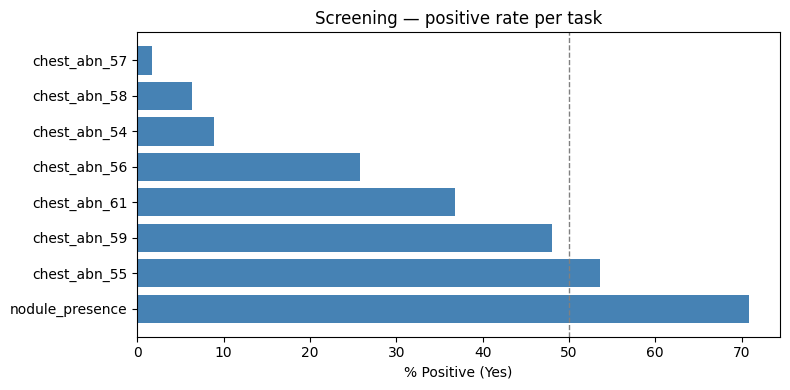

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(screen_df["task"], screen_df["%Yes"], color="steelblue")
ax.axvline(50, color="gray", ls="--", lw=1)
ax.set_xlabel("% Positive (Yes)")
ax.set_title("Screening — positive rate per task")
plt.tight_layout()
plt.show()